In [1]:

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import kagglehub

SEED = 42
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 12

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid", context="notebook")

DATASET_ID = "salader/dogsvscats"
dataset_path = Path(kagglehub.dataset_download(DATASET_ID))

print("Dataset path:")
print(dataset_path)
print("\nTop-level contents:")
for item in sorted(dataset_path.iterdir()):
    print(item.name)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Dataset path:
/kaggle/input/dogsvscats

Top-level contents:
catsvsdogs
test
train


In [2]:
train_dir = dataset_path / "train"
test_dir = dataset_path / "test"

if not train_dir.exists() or not test_dir.exists():
    train_matches = [p for p in dataset_path.rglob("train") if p.is_dir()]
    test_matches = [p for p in dataset_path.rglob("test") if p.is_dir()]
    train_dir = train_matches[0] if train_matches else train_dir
    test_dir = test_matches[0] if test_matches else test_dir

class_names = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])

print("Train directory:", train_dir)
print("Test directory:", test_dir)
print("Classes:", class_names)

Train directory: /kaggle/input/dogsvscats/train
Test directory: /kaggle/input/dogsvscats/test
Classes: ['cats', 'dogs']


In [3]:
def collect_image_counts(root):
    rows = []
    for class_name in sorted([p.name for p in root.iterdir() if p.is_dir()]):
        count = sum(1 for p in (root / class_name).rglob("*") if p.is_file())
        rows.append({"class": class_name, "images": count})
    return pd.DataFrame(rows)

train_counts = collect_image_counts(train_dir)
test_counts = collect_image_counts(test_dir)

stats_table = train_counts.merge(test_counts, on="class", suffixes=(" (train)", " (test)"))
display(stats_table)

,class,images (train),images (test)
0,cats,10000,2500
1,dogs,10000,2500


/tmp/ipykernel_6103/8905982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_6103/8905982.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


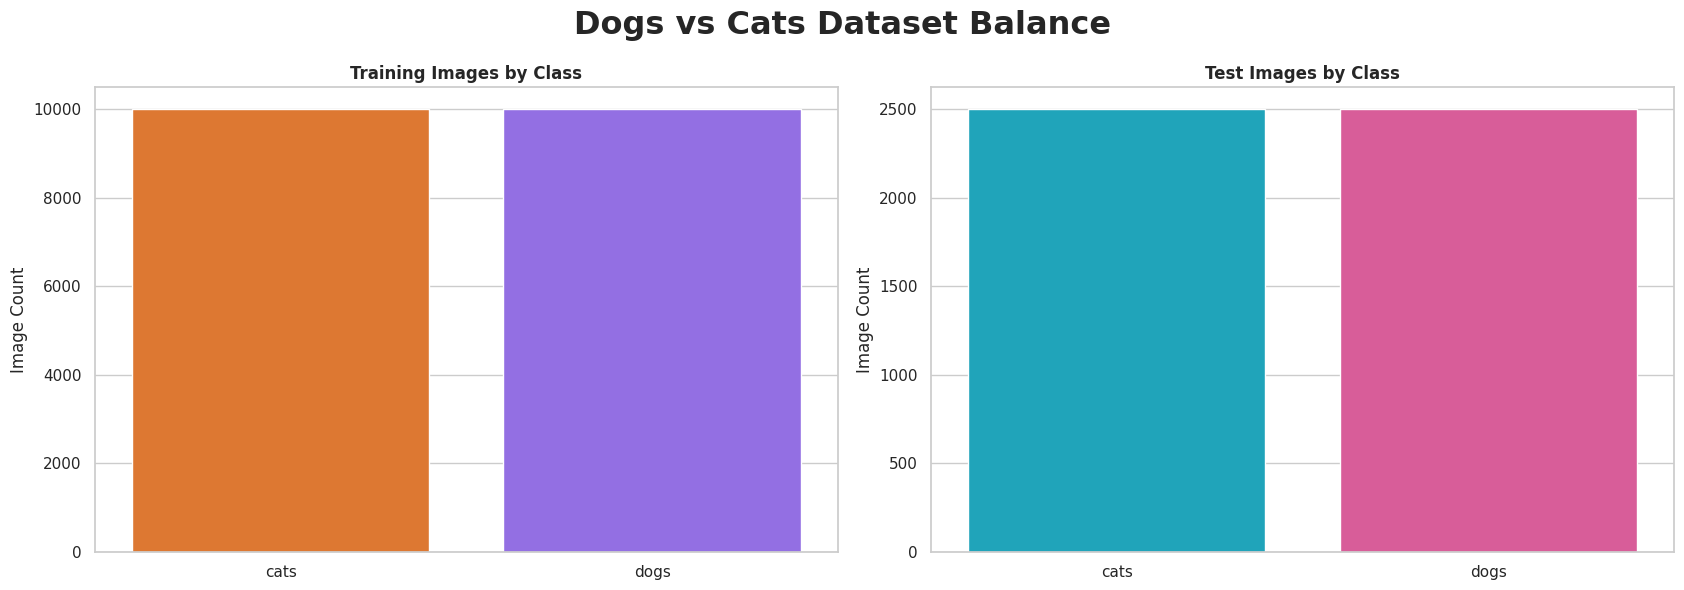

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.barplot(
    data=train_counts,
    x="class",
    y="images",
    ax=axes[0],
    palette=["#f97316", "#8b5cf6"]
)
axes[0].set_title("Training Images by Class", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Image Count")

sns.barplot(
    data=test_counts,
    x="class",
    y="images",
    ax=axes[1],
    palette=["#06b6d4", "#ec4899"]
)
axes[1].set_title("Test Images by Class", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Image Count")

plt.suptitle("Dogs vs Cats Dataset Balance", fontsize=23, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.20,
    subset="training"
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.20,
    subset="validation"
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Found 5000 files belonging to 2 classes.
Train batches: 500
Validation batches: 125
Test batches: 157


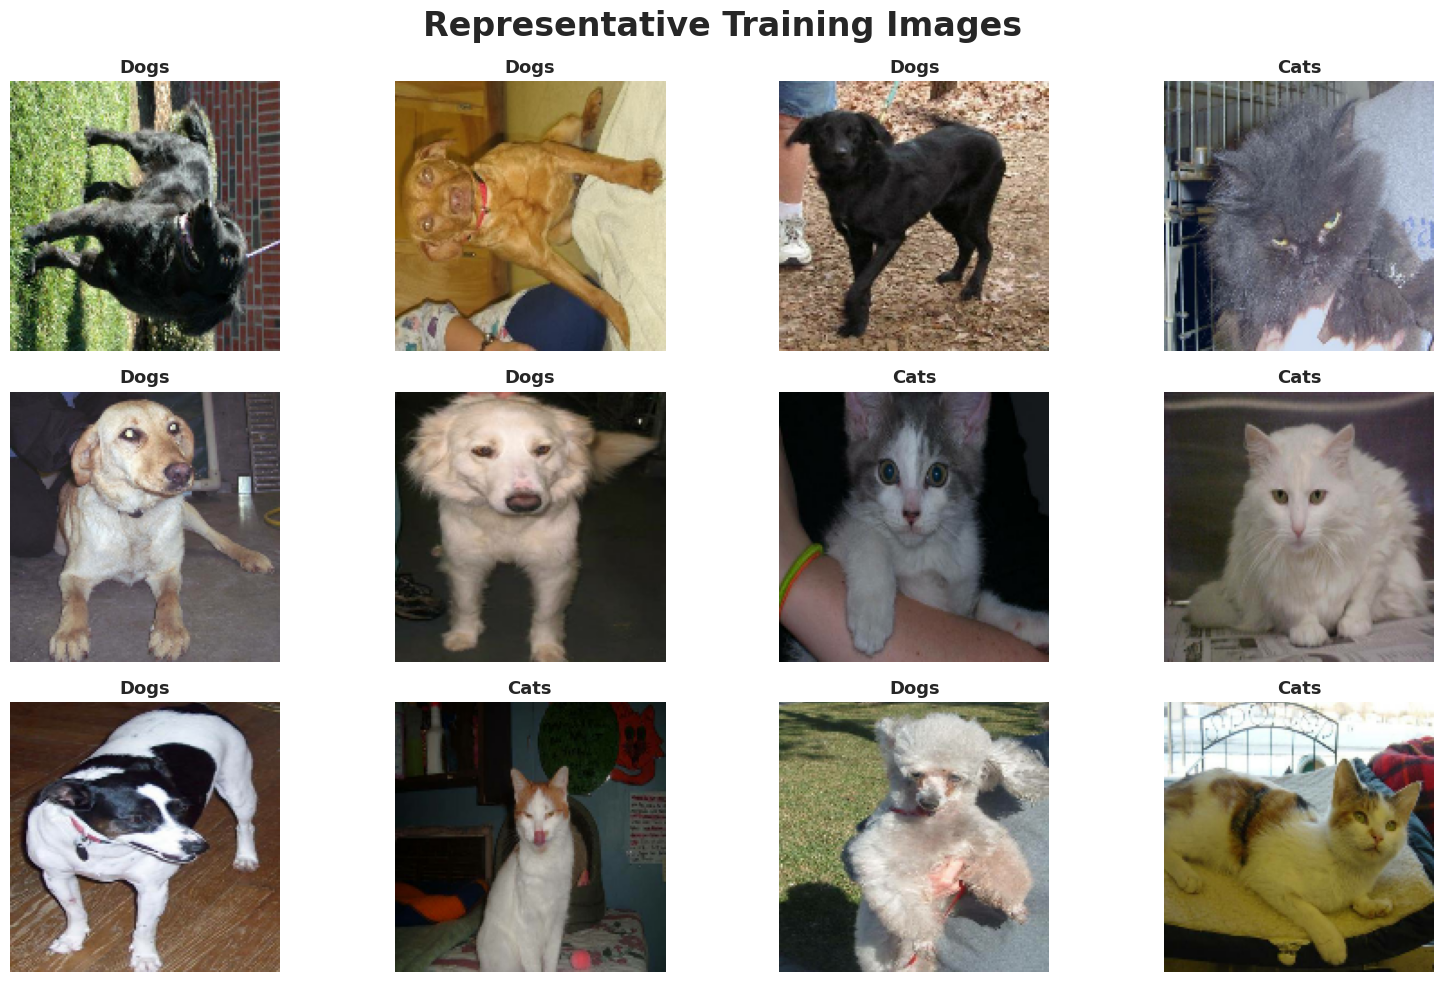

In [6]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(16, 10))

for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label_index = int(labels[i].numpy().reshape(-1)[0])
    plt.title(class_names[label_index].title(), fontsize=13, fontweight="bold")
    plt.axis("off")

plt.suptitle("Representative Training Images", fontsize=24, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
pixel_sample = images[0].numpy()

print("Image shape:", pixel_sample.shape)
print("Pixel minimum:", float(pixel_sample.min()))
print("Pixel maximum:", float(pixel_sample.max()))
print("Image dtype:", pixel_sample.dtype)

Image shape: (150, 150, 3)
Pixel minimum: 0.0
Pixel maximum: 255.0
Image dtype: float32


In [8]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False

model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.35),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
layer_table = pd.DataFrame({
    "Layer": [layer.name for layer in model.layers],
    "Trainable": [layer.trainable for layer in model.layers],
    "Parameters": [layer.count_params() for layer in model.layers]
})

display(layer_table)

print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(layer.count_params() for layer in model.layers if layer.trainable)
)

,Layer,Trainable,Parameters
0,lambda,True,0
1,vgg16,False,14714688
2,global_average_pooling2d,True,0
3,dense,True,131328
4,dropout,True,0
5,dense_1,True,257


Total parameters: 14846273
Trainable parameters: 131585


In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )
]

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 140ms/step - accuracy: 0.9528 - auc: 0.9786 - loss: 0.2725 - precision: 0.9514 - recall: 0.9539 - val_accuracy: 0.9653 - val_auc: 0.9943 - val_loss: 0.1050 - val_precision: 0.9828 - val_recall: 0.9486 - learning_rate: 0.0010
Epoch 2/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.9729 - auc: 0.9958 - loss: 0.0744 - precision: 0.9734 - recall: 0.9721 - val_accuracy: 0.9695 - val_auc: 0.9943 - val_loss: 0.0891 - val_precision: 0.9692 - val_recall: 0.9711 - learning_rate: 0.0010
Epoch 3/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.9798 - auc: 0.9974 - loss: 0.0571 - precision: 0.9802 - recall: 0.9791 - val_accuracy: 0.9722 - val_auc: 0.9954 - val_loss: 0.0821 - val_precision: 0.9773 - val_recall: 0.9682 - learning_rate: 0.0010
Epoch 4/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.9856 - auc: 0.9986 - loss: 0.0398 - precision: 0.9853 - recall: 0.9857 - val_accuracy: 0.9745 - val_auc: 0.9950 - val_loss: 

In [13]:
history_df = pd.DataFrame(history.history)
history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
display(history_df.round(4))

,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,1,0.9528,0.9786,0.2725,0.9514,0.9539,0.9653,0.9943,0.1050,0.9828,0.9486,0.0010
1,2,0.9729,0.9958,0.0744,0.9734,0.9721,0.9695,0.9943,0.0891,0.9692,0.9711,0.0010
2,3,0.9798,0.9974,0.0571,0.9802,0.9791,0.9722,0.9954,0.0821,0.9773,0.9682,0.0010
3,4,0.9856,0.9986,0.0398,0.9853,0.9857,0.9745,0.9950,0.0848,0.9788,0.9711,0.0010
4,5,0.9867,0.9986,0.0372,0.9872,0.9860,0.9735,0.9938,0.0959,0.9807,0.9672,0.0010
5,6,0.9929,0.9997,0.0197,0.9940,0.9918,0.9740,0.9944,0.0903,0.9778,0.9711,0.0003


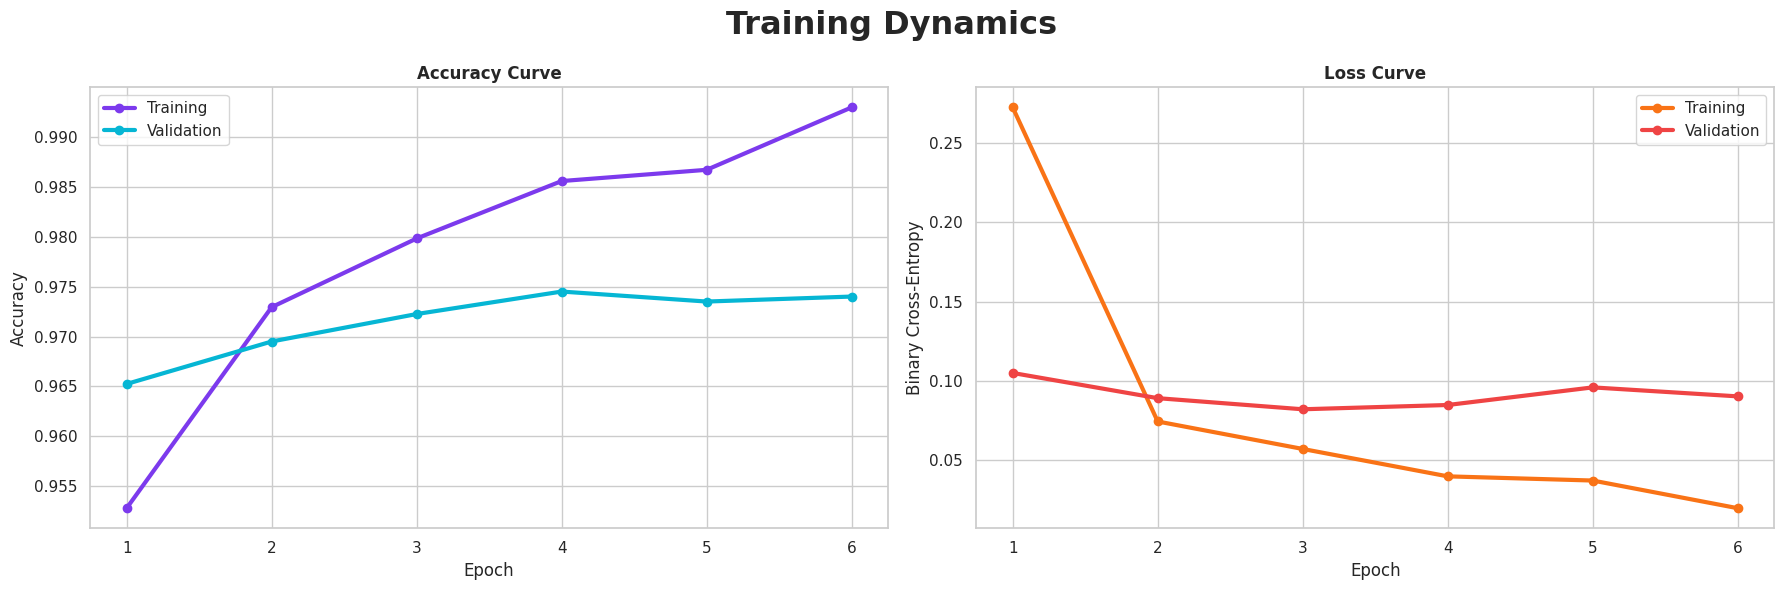

In [14]:
epochs = range(1, len(history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(epochs, history.history["accuracy"], marker="o", linewidth=3, color="#7c3aed", label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], marker="o", linewidth=3, color="#06b6d4", label="Validation")
axes[0].set_title("Accuracy Curve", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], marker="o", linewidth=3, color="#f97316", label="Training")
axes[1].plot(epochs, history.history["val_loss"], marker="o", linewidth=3, color="#ef4444", label="Validation")
axes[1].set_title("Loss Curve", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy")
axes[1].legend()

plt.suptitle("Training Dynamics", fontsize=23, fontweight="bold")
plt.tight_layout()
plt.show()


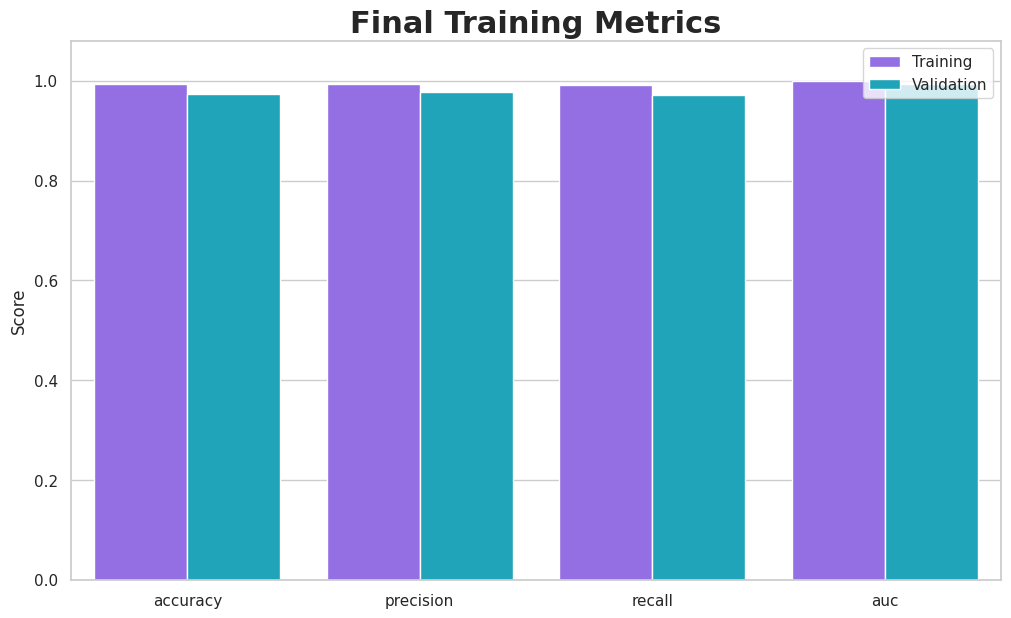

In [15]:
metric_names = ["accuracy", "precision", "recall", "auc"]

metric_plot = pd.DataFrame({
    "Metric": metric_names,
    "Training": [history.history[m][-1] for m in metric_names],
    "Validation": [history.history[f"val_{m}"][-1] for m in metric_names]
}).melt(id_vars="Metric", var_name="Split", value_name="Score")

plt.figure(figsize=(12, 7))
sns.barplot(
    data=metric_plot,
    x="Metric",
    y="Score",
    hue="Split",
    palette=["#8b5cf6", "#06b6d4"]
)
plt.ylim(0, 1.08)
plt.title("Final Training Metrics", fontsize=22, fontweight="bold")
plt.xlabel("")
plt.ylabel("Score")
plt.legend(title="")
plt.show()

In [16]:
test_results = model.evaluate(test_ds, verbose=0, return_dict=True)

results_df = pd.DataFrame({
    "Metric": list(test_results.keys()),
    "Value": list(test_results.values())
})

display(results_df.round(4))

,Metric,Value
0,accuracy,0.9712
1,auc,0.9959
2,loss,0.0814
3,precision,0.9781
4,recall,0.9640


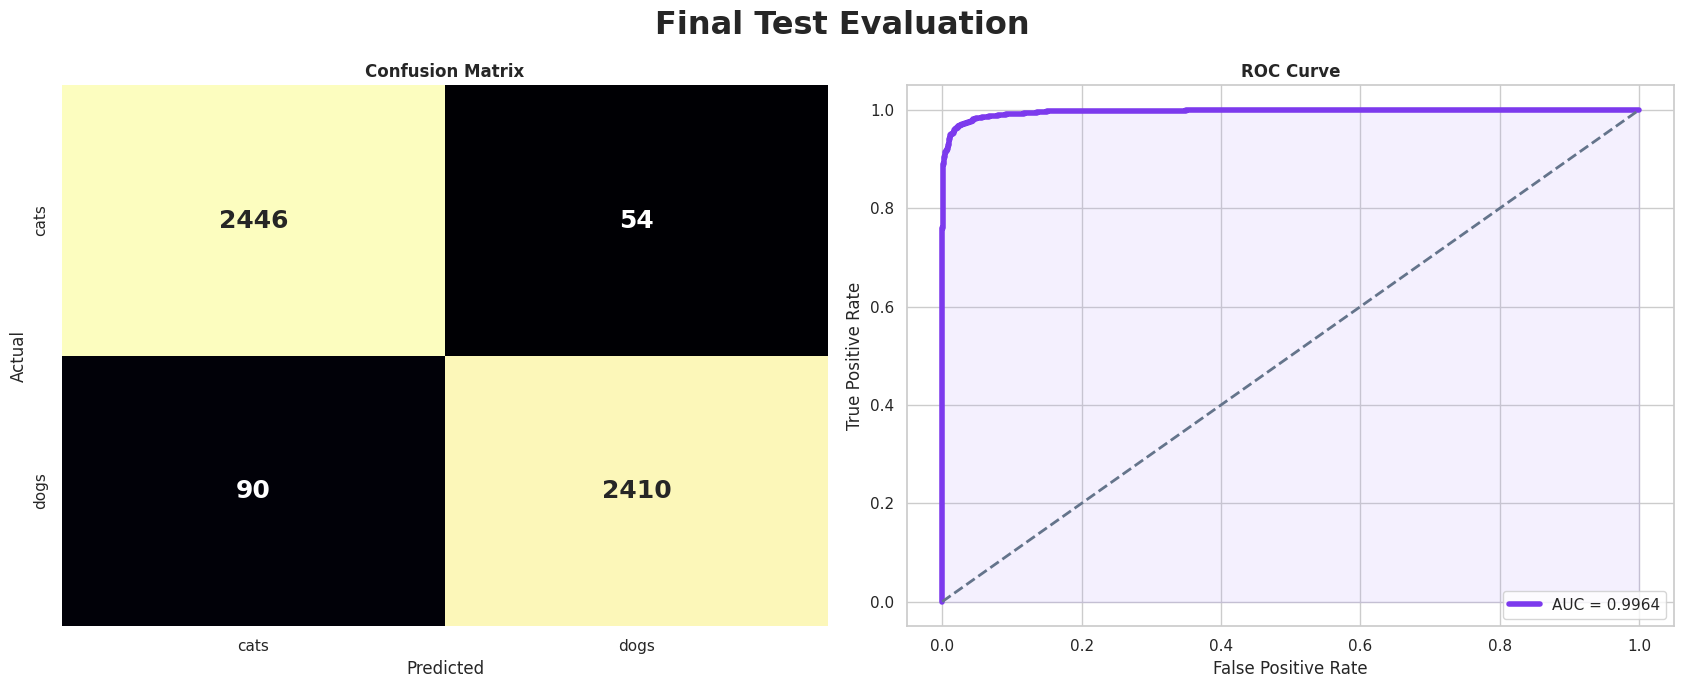

              precision    recall  f1-score   support

        cats     0.9645    0.9784    0.9714      2500
        dogs     0.9781    0.9640    0.9710      2500

    accuracy                         0.9712      5000
   macro avg     0.9713    0.9712    0.9712      5000
weighted avg     0.9713    0.9712    0.9712      5000



In [17]:
y_true = np.concatenate([
    y.numpy().reshape(-1)
    for _, y in test_ds
], axis=0).astype(int)

y_prob = model.predict(test_ds, verbose=0).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,
    ax=axes[0],
    annot_kws={"fontsize": 18, "fontweight": "bold"}
)
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(
    fpr,
    tpr,
    linewidth=4,
    color="#7c3aed",
    label=f"AUC = {roc_auc:.4f}"
)
axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    color="#64748b"
)
axes[1].fill_between(fpr, tpr, alpha=0.12, color="#a78bfa")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.suptitle("Final Test Evaluation", fontsize=23, fontweight="bold")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

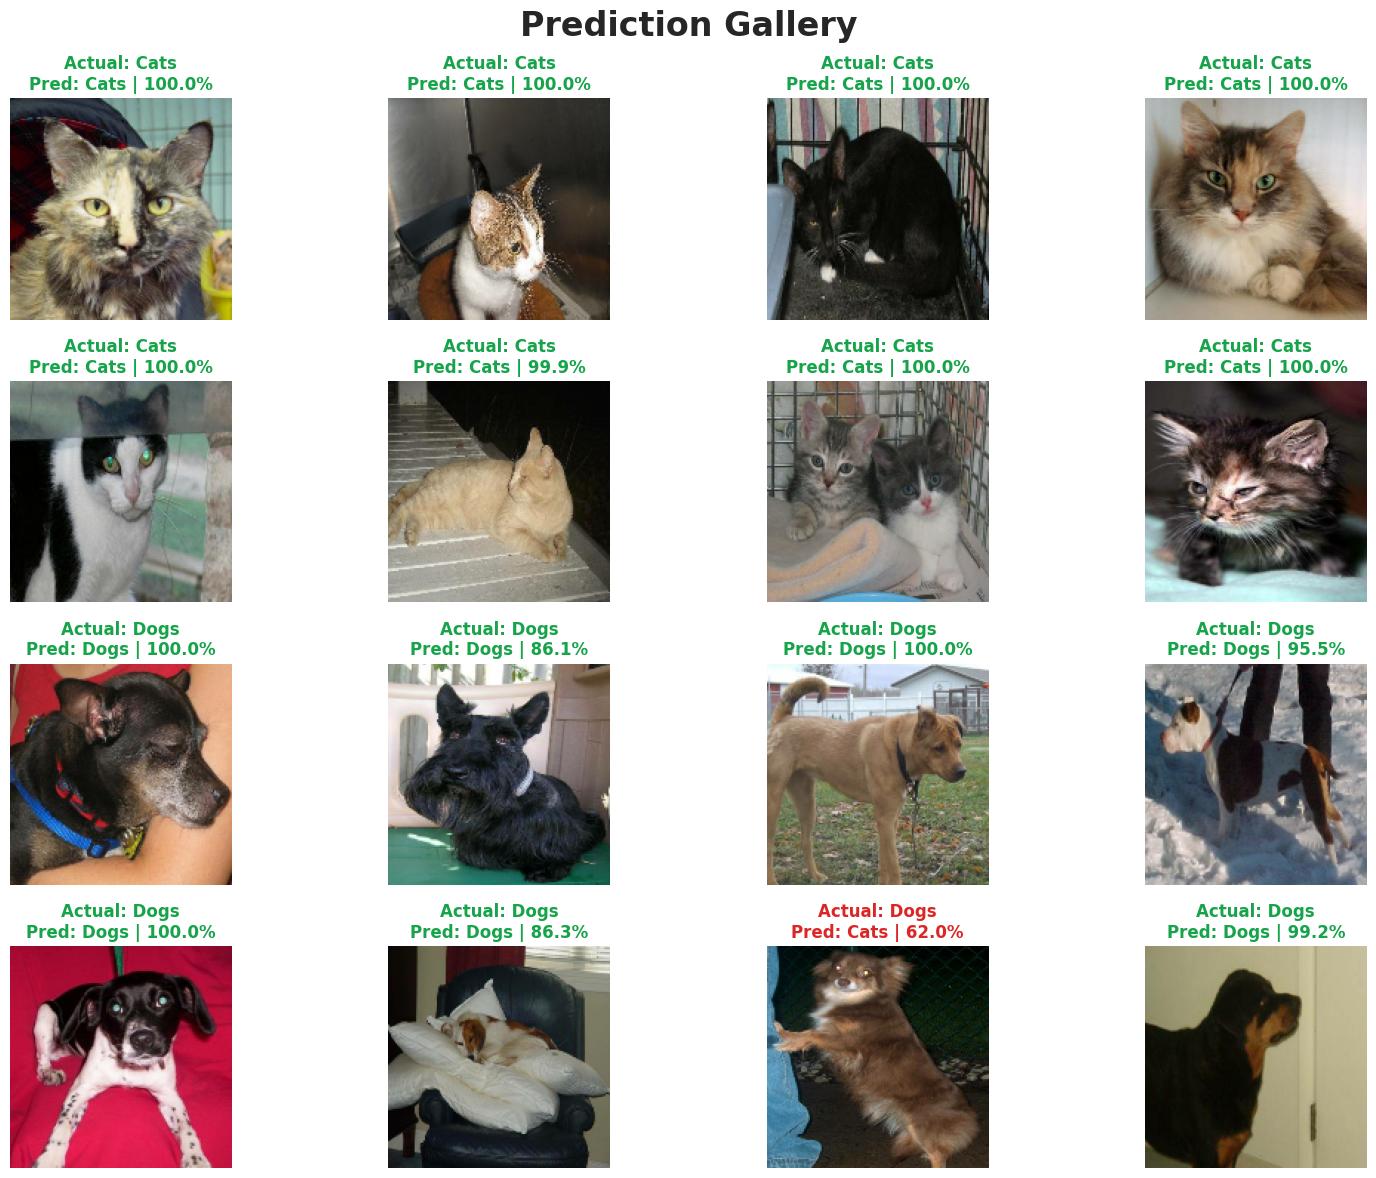

In [18]:
all_test_images = []
all_test_labels = []

for batch_images, batch_labels in test_ds:
    all_test_images.extend(batch_images.numpy())
    all_test_labels.extend(batch_labels.numpy().reshape(-1).astype(int))

all_test_images = np.array(all_test_images)
all_test_labels = np.array(all_test_labels)

sample_count = min(16, len(all_test_images))
sample_indices = np.linspace(0, len(all_test_images) - 1, sample_count, dtype=int)

sample_images = all_test_images[sample_indices]
sample_labels = all_test_labels[sample_indices]

sample_probs = model.predict(sample_images, verbose=0).reshape(-1)
sample_preds = (sample_probs >= 0.5).astype(int)

plt.figure(figsize=(16, 12))

for i in range(sample_count):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(sample_images[i].astype("uint8"))
    actual = class_names[sample_labels[i]].title()
    predicted = class_names[sample_preds[i]].title()
    confidence = sample_probs[i] if sample_preds[i] == 1 else 1 - sample_probs[i]
    title_color = "#16a34a" if sample_preds[i] == sample_labels[i] else "#dc2626"
    plt.title(
        f"Actual: {actual}\nPred: {predicted} | {confidence:.1%}",
        color=title_color,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle("Prediction Gallery", fontsize=24, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
model.save("dogs_vs_cats_vgg16_feature_extraction.keras")
print("Saved: dogs_vs_cats_vgg16_feature_extraction.keras")

Saved: dogs_vs_cats_vgg16_feature_extraction.keras
